# Smit Patel
#### First prompt: Explainme abot Frozenlake-v1
#### Last Prompt: How can I tune Model

In [1]:
pip install gymnasium


Note: you may need to restart the kernel to use updated packages.


Environment: FrozenLake-v1 (8x8, slippery)

Episodes: 20,000

Exploration: Epsilon-decay from 1.0 → 0.01

Update Rule: First-Visit Monte Carlo

Observation: Low reward and slow convergence

Best Average Return: 0.22
Episodes to reach 90% of best return: 8266
Converged at episode: 150
Avg time per episode: 0.0141 seconds


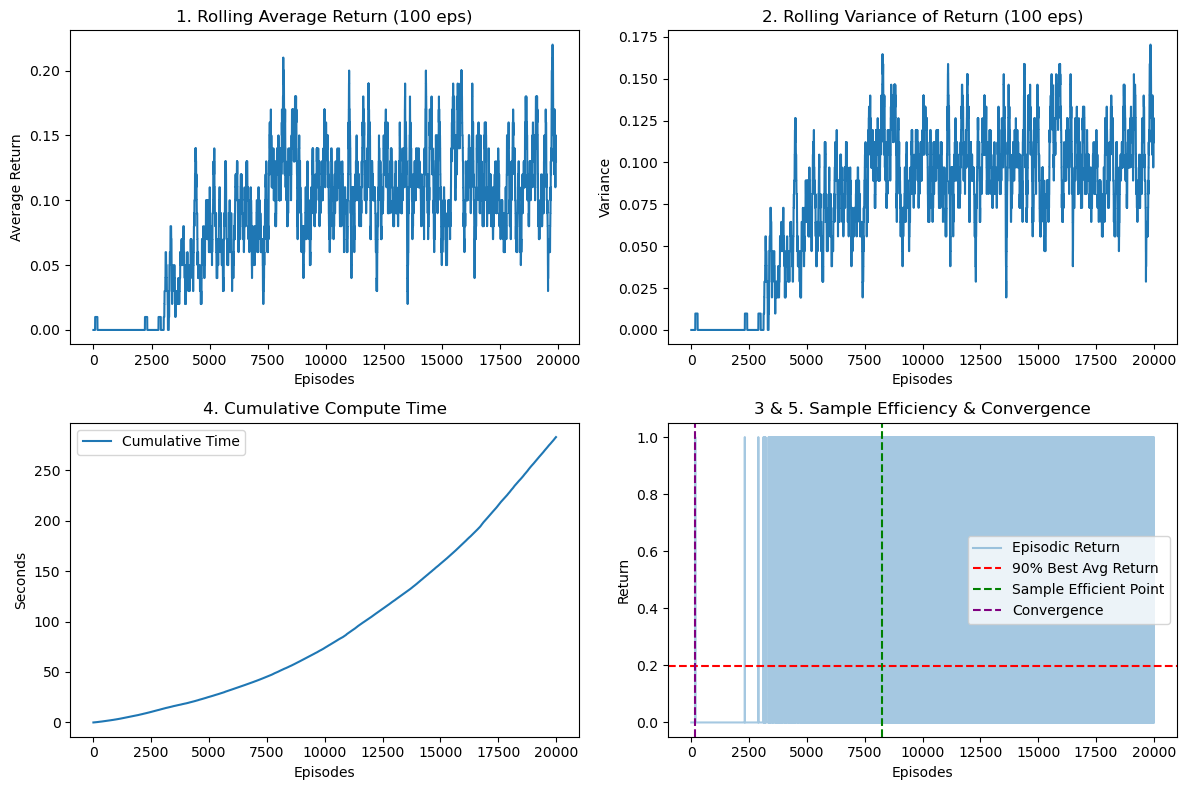

In [3]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import time
from collections import defaultdict

# Create FrozenLake 8x8
env = gym.make("FrozenLake-v1", map_name="8x8", is_slippery=True)

# Hyperparameters
num_episodes = 20000
gamma = 0.99
epsilon = 1.0
min_epsilon = 0.01
epsilon_decay = 0.9995

# Q-values and returns
Q = defaultdict(lambda: np.zeros(env.action_space.n))
returns = defaultdict(list)

# Metrics
episode_returns = []
episode_times = []

for episode in range(num_episodes):
    start_time = time.time()
    state, _ = env.reset()
    episode_data = []
    done = False

    # Generate episode
    while not done:
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q[state])
        next_state, reward, terminated, truncated, _ = env.step(action)
        episode_data.append((state, action, reward))
        state = next_state
        done = terminated or truncated

    # First-Visit Monte Carlo Update
    G = 0
    visited = set()
    for t in reversed(range(len(episode_data))):
        s, a, r = episode_data[t]
        G = gamma * G + r
        if (s, a) not in visited:
            visited.add((s, a))
            returns[(s, a)].append(G)
            Q[s][a] = np.mean(returns[(s, a)])

    episode_returns.append(sum([x[2] for x in episode_data]))
    episode_times.append(time.time() - start_time)

    # Decay epsilon
    epsilon = max(min_epsilon, epsilon * epsilon_decay)

# ------------------------------
# Evaluation Metrics
# ------------------------------

window = 100
rolling_avg = np.convolve(episode_returns, np.ones(window)/window, mode='valid')
rolling_var = [np.var(episode_returns[max(0, i - window):i+1]) for i in range(len(episode_returns))]

best_avg_return = max(rolling_avg)
threshold = 0.9 * best_avg_return

# Sample Efficiency: episodes to reach 90% of best return
sample_efficiency = None
for i in range(len(rolling_avg)):
    if rolling_avg[i] >= threshold:
        sample_efficiency = i + window
        break

# Convergence: when returns stabilize
def is_stable(vals, threshold=1e-2, min_len=50):
    if len(vals) < min_len:
        return False
    recent = vals[-min_len:]
    return max(recent) - min(recent) < threshold

converged_at = None
for i in range(len(rolling_avg)):
    if is_stable(rolling_avg[:i]):
        converged_at = i + window
        break

# Results
print(f"Best Average Return: {best_avg_return:.2f}")
print(f"Episodes to reach 90% of best return: {sample_efficiency}")
print(f"Converged at episode: {converged_at}")
print(f"Avg time per episode: {np.mean(episode_times):.4f} seconds")

# ------------------------------
# Plots
# ------------------------------
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(rolling_avg)
plt.title("1. Rolling Average Return (100 eps)")
plt.xlabel("Episodes")
plt.ylabel("Average Return")

plt.subplot(2, 2, 2)
plt.plot(rolling_var)
plt.title("2. Rolling Variance of Return (100 eps)")
plt.xlabel("Episodes")
plt.ylabel("Variance")

plt.subplot(2, 2, 3)
plt.plot(np.cumsum(episode_times), label="Cumulative Time")
plt.title("4. Cumulative Compute Time")
plt.xlabel("Episodes")
plt.ylabel("Seconds")
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(episode_returns, alpha=0.4, label="Episodic Return")
plt.axhline(y=threshold, color='r', linestyle='--', label="90% Best Avg Return")
if sample_efficiency:
    plt.axvline(x=sample_efficiency, color='g', linestyle='--', label="Sample Efficient Point")
if converged_at:
    plt.axvline(x=converged_at, color='purple', linestyle='--', label="Convergence")
plt.title("3 & 5. Sample Efficiency & Convergence")
plt.xlabel("Episodes")
plt.ylabel("Return")
plt.legend()

plt.tight_layout()
plt.show()


# Tuning 
Conducted hyperparameter tuning by testing different combinations of Gamma (γ) and Epsilon Decay.

Evaluated each configuration using metrics like best average return, sample efficiency, convergence, and time per episode.
Identified and reported the optimal hyperparameters that yielded the highest and most stable returns.

In [14]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import time
from collections import defaultdict

def run_mc(env, gamma, epsilon_decay, num_episodes=20000, epsilon=1.0, min_epsilon=0.01):
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    returns = defaultdict(list)
    episode_returns = []
    episode_times = []

    for episode in range(num_episodes):
        start_time = time.time()
        state, _ = env.reset()
        episode_data = []
        done = False

        while not done:
            if np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(Q[state])
            next_state, reward, terminated, truncated, _ = env.step(action)
            episode_data.append((state, action, reward))
            state = next_state
            done = terminated or truncated

        # First-Visit MC
        G = 0
        visited = set()
        for t in reversed(range(len(episode_data))):
            s, a, r = episode_data[t]
            G = gamma * G + r
            if (s, a) not in visited:
                visited.add((s, a))
                returns[(s, a)].append(G)
                Q[s][a] = np.mean(returns[(s, a)])

        episode_returns.append(sum([x[2] for x in episode_data]))
        episode_times.append(time.time() - start_time)

        # Decay epsilon
        epsilon = max(min_epsilon, epsilon * epsilon_decay)

    return episode_returns, episode_times


def evaluate(episode_returns, episode_times):
    window = 100
    rolling_avg = np.convolve(episode_returns, np.ones(window)/window, mode='valid')
    rolling_var = [np.var(episode_returns[max(0, i - window):i+1]) for i in range(len(episode_returns))]

    best_avg_return = max(rolling_avg)
    threshold = 0.9 * best_avg_return

    # Sample efficiency
    sample_efficiency = next((i + window for i, val in enumerate(rolling_avg) if val >= threshold), None)

    # Convergence
    def is_stable(vals, threshold=1e-2, min_len=50):
        if len(vals) < min_len:
            return False
        recent = vals[-min_len:]
        return max(recent) - min(recent) < threshold

    converged_at = next((i + window for i in range(len(rolling_avg)) if is_stable(rolling_avg[:i])), None)

    return best_avg_return, sample_efficiency, converged_at, np.mean(episode_times)


# ------------------------------
# Hyperparameter Tuning Grid
# ------------------------------
env = gym.make("FrozenLake-v1", map_name="8x8", is_slippery=True)

param_grid = [
    {"gamma": 0.99, "epsilon_decay": 0.9995},
    {"gamma": 0.98, "epsilon_decay": 0.999},
    {"gamma": 0.95, "epsilon_decay": 0.9995},
    {"gamma": 0.99, "epsilon_decay": 0.9992},
    {"gamma": 0.97, "epsilon_decay": 0.9993},
]

results = []
for config in param_grid:
    print(f"\nRunning config: {config}")
    returns, times = run_mc(env, **config)
    metrics = evaluate(returns, times)
    results.append((config, *metrics))
    print(f" → BestAvgReturn: {metrics[0]:.4f}, SampleEff: {metrics[1]}, ConvergedAt: {metrics[2]}, Time/Episode: {metrics[3]:.4f}")

# ------------------------------
# Print Best Configuration
# ------------------------------
best_result = max(results, key=lambda x: x[1])  # based on best average return
print("\n✅ Best Configuration:")
print(f"Gamma: {best_result[0]['gamma']}, Epsilon Decay: {best_result[0]['epsilon_decay']}")
print(f"Best Avg Return: {best_result[1]:.4f}")
print(f"Episodes to reach 90% of best return: {best_result[2]}")
print(f"Converged at: {best_result[3]}")
print(f"Avg time per episode: {best_result[4]:.4f}")



Running config: {'gamma': 0.99, 'epsilon_decay': 0.9995}
 → BestAvgReturn: 0.0000, SampleEff: 100, ConvergedAt: 150, Time/Episode: 0.0125

Running config: {'gamma': 0.98, 'epsilon_decay': 0.999}
 → BestAvgReturn: 0.0400, SampleEff: 14183, ConvergedAt: 150, Time/Episode: 0.0106

Running config: {'gamma': 0.95, 'epsilon_decay': 0.9995}
 → BestAvgReturn: 0.1300, SampleEff: 15870, ConvergedAt: 186, Time/Episode: 0.0118

Running config: {'gamma': 0.99, 'epsilon_decay': 0.9992}
 → BestAvgReturn: 0.0100, SampleEff: 461, ConvergedAt: 150, Time/Episode: 0.0092

Running config: {'gamma': 0.97, 'epsilon_decay': 0.9993}
 → BestAvgReturn: 0.4700, SampleEff: 6573, ConvergedAt: 153, Time/Episode: 0.0165

✅ Best Configuration:
Gamma: 0.97, Epsilon Decay: 0.9993
Best Avg Return: 0.4700
Episodes to reach 90% of best return: 6573
Converged at: 153
Avg time per episode: 0.0165


In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import time
from collections import defaultdict

def run_mc(env, gamma, epsilon_decay, num_episodes=50000, epsilon=1.0, min_epsilon=0.01):
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    returns = defaultdict(list)
    episode_returns = []
    episode_times = []

    for episode in range(num_episodes):
        start_time = time.time()
        state, _ = env.reset()
        episode_data = []
        done = False

        while not done:
            if np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(Q[state])
            next_state, reward, terminated, truncated, _ = env.step(action)
            episode_data.append((state, action, reward))
            state = next_state
            done = terminated or truncated

        # First-Visit MC
        G = 0
        visited = set()
        for t in reversed(range(len(episode_data))):
            s, a, r = episode_data[t]
            G = gamma * G + r
            if (s, a) not in visited:
                visited.add((s, a))
                returns[(s, a)].append(G)
                Q[s][a] = np.mean(returns[(s, a)])

        episode_returns.append(sum([x[2] for x in episode_data]))
        episode_times.append(time.time() - start_time)

        # Decay epsilon
        epsilon = max(min_epsilon, epsilon * epsilon_decay)

    return episode_returns, episode_times


def evaluate(episode_returns, episode_times):
    window = 100
    rolling_avg = np.convolve(episode_returns, np.ones(window)/window, mode='valid')
    rolling_var = [np.var(episode_returns[max(0, i - window):i+1]) for i in range(len(episode_returns))]

    best_avg_return = max(rolling_avg)
    threshold = 0.9 * best_avg_return

    # Sample efficiency
    sample_efficiency = next((i + window for i, val in enumerate(rolling_avg) if val >= threshold), None)

    # Convergence
    def is_stable(vals, threshold=1e-2, min_len=50):
        if len(vals) < min_len:
            return False
        recent = vals[-min_len:]
        return max(recent) - min(recent) < threshold

    converged_at = next((i + window for i in range(len(rolling_avg)) if is_stable(rolling_avg[:i])), None)

    return best_avg_return, sample_efficiency, converged_at, np.mean(episode_times)


# ------------------------------
# Hyperparameter Tuning Grid
# ------------------------------
env = gym.make("FrozenLake-v1", map_name="8x8", is_slippery=True)

param_grid = [
    {"gamma": 0.99, "epsilon_decay": 0.9995},
    {"gamma": 0.98, "epsilon_decay": 0.999},
    {"gamma": 0.95, "epsilon_decay": 0.9995},
    {"gamma": 0.99, "epsilon_decay": 0.9992},
    {"gamma": 0.97, "epsilon_decay": 0.9993},
]

results = []
for config in param_grid:
    print(f"\nRunning config: {config}")
    returns, times = run_mc(env, **config)
    metrics = evaluate(returns, times)
    results.append((config, *metrics))
    print(f" → BestAvgReturn: {metrics[0]:.4f}, SampleEff: {metrics[1]}, ConvergedAt: {metrics[2]}, Time/Episode: {metrics[3]:.4f}")

# ------------------------------
# Print Best Configuration
# ------------------------------
best_result = max(results, key=lambda x: x[1])  # based on best average return
print("\n✅ Best Configuration:")
print(f"Gamma: {best_result[0]['gamma']}, Epsilon Decay: {best_result[0]['epsilon_decay']}")
print(f"Best Avg Return: {best_result[1]:.4f}")
print(f"Episodes to reach 90% of best return: {best_result[2]}")
print(f"Converged at: {best_result[3]}")
print(f"Avg time per episode: {best_result[4]:.4f}")



Running config: {'gamma': 0.99, 'epsilon_decay': 0.9995}
